In [16]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
import os
from dotenv import load_dotenv

load_dotenv()

def get_chat():
    llm = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-8B-Instruct",
        huggingfacehub_api_token=os.environ["HUGGINGFACEHUB_API_TOKEN"],
        temperature=0,
    )
    return ChatHuggingFace(llm=llm)

In [32]:
from typing import TypedDict,Annotated
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
import operator

In [18]:
model = get_chat()

In [19]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Feedback on the essay")
    score : int = Field(description="Score for the essay",ge=0, le=10)

In [ ]:

# template for structured output from LLM 
from html import parser
from prompt_toolkit import prompt


def structured_invoke(model, schema, user_input):
    parser = PydanticOutputParser(pydantic_object=schema)

    prompt=PromptTemplate(
    template="Give a score for the essay in the format {JSON_FORMAT}.\n\n Essay: {user_input}",
    input_variables=["user_input"],
    partial_variables={"JSON_FORMAT":parser.get_format_instructions()})   
    
    formatted_prompt = prompt.format(user_input=user_input)
    response = model.invoke(formatted_prompt)
    return parser.parse(response.content)


In [ ]:
model = get_chat()
model.invoke("Write an essay on the impact of artificial intelligence on modern society.")  
structured_invoke(model, EvaluationSchema, "The Impact of Artificial Intelligence on Modern Society\n\nArtificial intelligence (AI) has revolutionized the way we live, work, and interact with each other. Over the past few decades, AI has made tremendous progress, transforming from a mere concept to a ubiquitous technology that has permeated various aspects of modern society. From intelligent personal assistants to self-driving cars, AI has become an integral part of our daily lives. However, its impact on society is multifaceted and far-reaching, with both positive and negative consequences.\n\nOn the positive side, AI has brought about numerous benefits to modern society. One of the most significant advantages is its ability to automate repetitive and mundane tasks, freeing humans from monotonous work and allowing them to focus on more creative and high-value tasks. For instance, AI-powered chatbots have taken over customer service, providing 24/7 support to customers and improving overall customer experience. Additionally, AI has also improved healthcare outcomes by analyzing medical data, detecting diseases earlier, and providing personalized treatment plans.\n\nAnother significant impact of AI is its ability to improve efficiency and productivity. With AI-powered tools, businesses can streamline their operations, reduce costs, and increase revenue. For example, AI-powered supply chain management systems can optimize inventory levels, reduce shipping times, and improve logistics. Furthermore, AI has also transformed the education sector by providing personalized learning experiences, improving student outcomes, and enhancing teacher productivity.\n\nHowever, the impact of AI on modern society is not without its challenges. One of the most significant concerns is job displacement. As AI takes over repetitive and mundane tasks, there is a risk of job losses, particularly in sectors where tasks are highly automatable. According to a report by the McKinsey Global Institute, up to 800 million jobs could be lost worldwide due to automation by 2030. This has raised concerns about the future of work, with many experts predicting that humans will need to adapt to new roles and skills that are complementary to AI.\n\nAnother concern is the potential for AI to exacerbate existing social inequalities. For instance, AI-powered systems can perpetuate biases in hiring, lending, and other decision-making processes, leading to discriminatory outcomes. Additionally, AI has also raised concerns about data privacy and security, as large amounts of personal data are collected and analyzed by AI systems. This has led to calls for greater regulation and oversight of AI development and deployment.\n\nFinally, the impact of AI on modern society also raises ethical concerns. As AI becomes more autonomous and intelligent, there is a risk of creating a new class of superintelligent")

EvaluationSchema(feedback='The essay provides a comprehensive overview of the impact of artificial intelligence on modern society, discussing both the benefits and challenges. It explores various aspects, including automation, efficiency, education, job displacement, and social inequalities. The writer presents a balanced view, acknowledging the positive and negative consequences of AI. However, some points could have been further elaborated, and the transition between paragraphs could be smoother. Overall, the essay demonstrates a good understanding of the topic and presents a well-structured argument.', score=8)

In [ ]:
# starting with UPSC essay workflow

class UPSC_Essay_State(TypedDict):
    essay: str
    language_feedback: str
    depth_of_analysis_feedback: str
    clarity_feedback: int
    overall_score: int
    # merging the values from the parallel workflow
    # remember the order is not guarenteed
    individual_scores : Annotated[list[int], operator.add]
    average_score : float
    overall_feedback: str

In [34]:
def evaluate_language(state:UPSC_Essay_State):
    # evaluate the language of the essay and return feedback
    user_input= state['essay']
    result = structured_invoke(model, EvaluationSchema, user_input)
    return {"language_feedback": result.feedback, "individual_scores":[result.score]}

def evaluate_depth_of_analysis(state:UPSC_Essay_State):
    # evaluate the depth of analysis of the essay and return feedback
    user_input= state['essay']
    result = structured_invoke(model, EvaluationSchema, user_input)
    return {"depth_of_analysis_feedback": result.feedback, "individual_scores":[result.score]}

def evaluate_clarity(state:UPSC_Essay_State):
    # evaluate the clarity of the essay and return feedback
    user_input= state['essay']
    result = structured_invoke(model, EvaluationSchema, user_input)
    return {"clarity_feedback": result.feedback, "individual_scores":[result.score]}

def final_evaluation(state:UPSC_Essay_State):
    # calculate the average score and return the final evaluation
    individual_scores = state['individual_scores']
    average_score = sum(individual_scores)/len(individual_scores)
    #generate overall feedback based on the individual feedback
    feedbacks = [state['language_feedback'], state['depth_of_analysis_feedback'], state['clarity_feedback']]
    chat_input = "The individual feedback for the essay is as follows:\n\n"
    chat_input += f"Language Feedback: {state['language_feedback']}\n\n"
    chat_input += f"Depth of Analysis Feedback: {state['depth_of_analysis_feedback']}\n\n"
    chat_input += f"Clarity Feedback: {state['clarity_feedback']}\n\n"
    chat_input += "Based on the above feedback, provide an overall feedback for the essay."
    overall_feedback = model.invoke(chat_input).content    
    return {"overall_score": average_score, "average_score": average_score, "overall_feedback": overall_feedback}

    

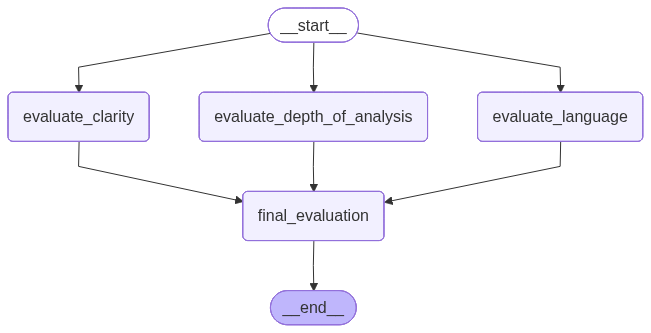

In [33]:
graph=StateGraph(UPSC_Essay_State)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_depth_of_analysis', evaluate_depth_of_analysis)
graph.add_node('evaluate_clarity', evaluate_clarity)
graph.add_node('final_evaluation', final_evaluation)

graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_depth_of_analysis')
graph.add_edge(START, 'evaluate_clarity')
graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_depth_of_analysis', 'final_evaluation')
graph.add_edge('evaluate_clarity', 'final_evaluation')
graph.add_edge('final_evaluation', END)

workflow = graph.compile()
workflow



In [38]:
initial_state = {
    "essay": "The Impact of Artificial Intelligence on Modern is  Society\n\nArtificial intelligence (AI) has revolutionized the way we live, work, and interact with each other. Over the past few decades, AI has made tremendous progress, transforming from a mere concept to a ubiquitous technology that has permeated various aspects of modern society. From intelligent personal assistants to self-driving cars, AI has become an integral part of our daily lives. However, its impact on society is multifaceted and far-reaching, with both positive and negative consequences.\n\nOn the positive side, AI has brought about numerous benefits to modern society. One of the most significant advantages is its ability to automate repetitive and mundane tasks "
}     
workflow.invoke(initial_state)              

{'essay': 'The Impact of Artificial Intelligence on Modern is  Society\n\nArtificial intelligence (AI) has revolutionized the way we live, work, and interact with each other. Over the past few decades, AI has made tremendous progress, transforming from a mere concept to a ubiquitous technology that has permeated various aspects of modern society. From intelligent personal assistants to self-driving cars, AI has become an integral part of our daily lives. However, its impact on society is multifaceted and far-reaching, with both positive and negative consequences.\n\nOn the positive side, AI has brought about numerous benefits to modern society. One of the most significant advantages is its ability to automate repetitive and mundane tasks ',
 'language_feedback': 'The essay provides a clear and well-structured overview of the impact of artificial intelligence on modern society. It highlights both the positive and negative consequences of AI, demonstrating a comprehensive understanding o